# Support Vector Machines
## TTK4260 — Multivariate Data Analysis & Machine Learning
**Department of Engineering Cybernetics, NTNU** | Adil Rasheed | Spring 2026

---

### Lecture Overview

This notebook accompanies the SVM lecture slides and covers all six modules:

| # | Module | Time |
|---|--------|------|
| 1 | Motivation & Geometric Intuition | ~10 min |
| 2 | Hard-Margin SVM | ~10 min |
| 3 | Dual Problem & Support Vectors | ~10 min |
| 4 | Soft-Margin SVM | ~10 min |
| 5 | The Kernel Trick | ~12 min |
| 6 | Practical Considerations | ~8 min |

> **Prerequisites:** Logistic Regression (decision boundaries, MLE), PCA (feature spaces), linear algebra.

---

In [1]:
# ============================================================
# Setup & Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_circles, make_moons, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ---- Plotting style ----
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

# NTNU-inspired colour palette
BRAND_BLUE   = '#00509E'
SOFT_BLUE    = '#C8DAEA'
ACCENT_GREEN = '#2CA02C'
ACCENT_ORANGE= '#FF7F0E'
RED          = '#D62728'

print('All packages loaded successfully!')

All packages loaded successfully!


---
## Part 1 — Motivation & Geometric Intuition

### 1.1  From Logistic Regression to SVM

Given a **linearly separable** binary dataset, **infinitely many hyperplanes** can separate the two classes.  
Different algorithms make different choices:

| Algorithm | Objective | Output |
|-----------|-----------|--------|
| Perceptron | Find *any* valid separator | Class label |
| Logistic Regression | Maximise log-likelihood | Probability |
| **SVM** | **Maximise geometric margin** | **Class label** |

The key SVM insight: the **maximum-margin hyperplane** is the one that is **furthest from all training points**.  
Only the **support vectors** — the closest points to the boundary — define this hyperplane.

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


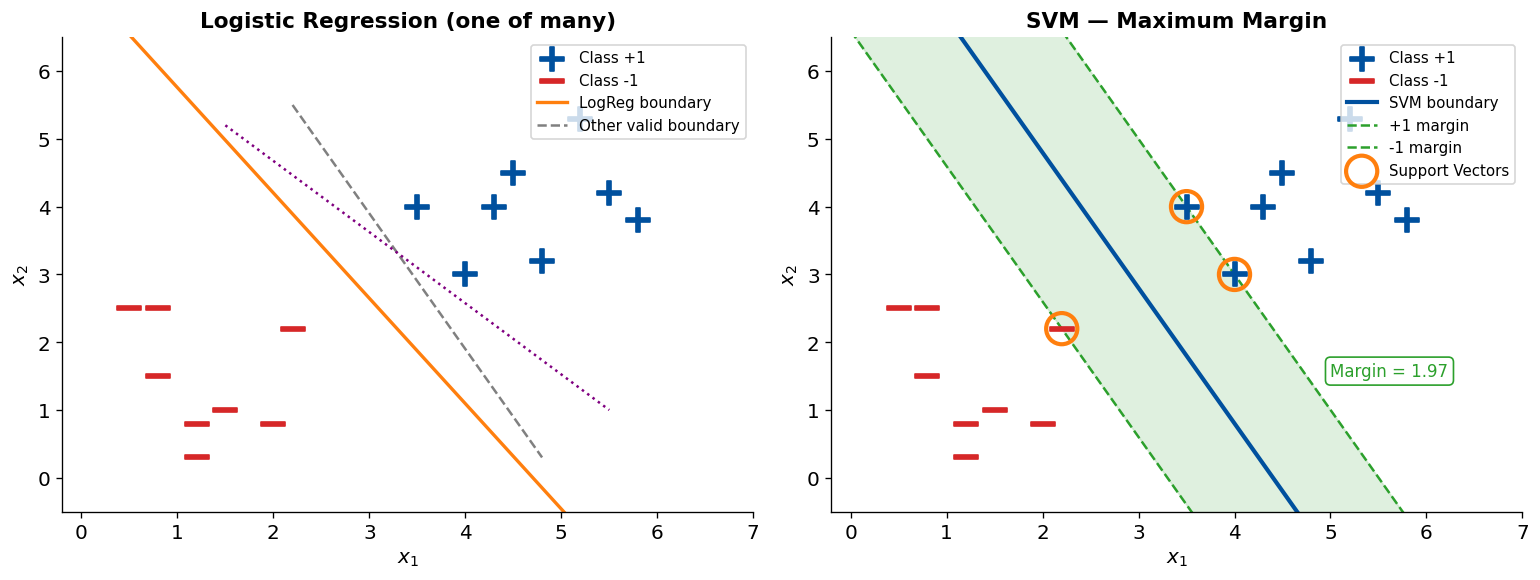

Number of support vectors: 3
Support vector indices: [14  0  1]
Geometric margin (2/||w||) = 1.9677


In [2]:
# ============================================================
# 1.2  Visualise multiple valid boundaries vs. the SVM boundary
# ============================================================
np.random.seed(0)
X_pos = np.array([[3.5,4.0],[4.0,3.0],[4.5,4.5],[4.8,3.2],[5.5,4.2],[5.2,5.3],[4.3,4.0],[5.8,3.8]])
X_neg = np.array([[0.8,1.5],[1.2,0.8],[0.5,2.5],[1.5,1.0],[2.0,0.8],[1.2,0.3],[2.2,2.2],[0.8,2.5]])
X_demo = np.vstack([X_pos, X_neg])
y_demo = np.array([1]*len(X_pos) + [-1]*len(X_neg))

# Fit SVM to get the optimal boundary
svm_demo = SVC(kernel='linear', C=1e6)   # large C ≈ hard margin
svm_demo.fit(X_demo, y_demo)
w = svm_demo.coef_[0]
b = svm_demo.intercept_[0]

# Helper: draw a hyperplane  w[0]*x + w[1]*y + b = offset
def plot_line(ax, w, b, x_range, offset=0, **kwargs):
    x = np.linspace(*x_range, 200)
    y = -(w[0]*x + b + offset) / w[1]
    ax.plot(x, y, **kwargs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, title in zip(axes, ['Logistic Regression (one of many)', 'SVM — Maximum Margin']):
    ax.scatter(*X_pos.T, marker='$+$', s=200, color=BRAND_BLUE,    label='Class +1', zorder=3)
    ax.scatter(*X_neg.T, marker='$-$', s=200, color=RED,           label='Class -1', zorder=3)
    ax.set_xlim(-0.2, 7); ax.set_ylim(-0.5, 6.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)

# Left: Logistic regression + two additional arbitrary boundaries
lr = LogisticRegression(C=1e6).fit(X_demo, y_demo)
w_lr = lr.coef_[0]; b_lr = lr.intercept_[0]
plot_line(axes[0], w_lr, b_lr, (0, 7), color=ACCENT_ORANGE,  lw=2, label='LogReg boundary')
axes[0].plot([2.2, 4.8], [5.5, 0.3], '--', color='grey',  lw=1.5, label='Other valid boundary')
axes[0].plot([1.5, 5.5], [5.2, 1.0], ':',  color='purple', lw=1.5)
axes[0].legend(fontsize=9)

# Right: SVM boundary + margin band + support vectors
margin = 1.0 / np.linalg.norm(w)
x_range = np.array([0, 7])
plot_line(axes[1], w, b, x_range, offset=0,   color=BRAND_BLUE,    lw=2.5, label='SVM boundary')
plot_line(axes[1], w, b, x_range, offset=-1,  color=ACCENT_GREEN,  lw=1.5, ls='--', label='+1 margin')
plot_line(axes[1], w, b, x_range, offset=+1,  color=ACCENT_GREEN,  lw=1.5, ls='--', label='-1 margin')

# Shade margin band
x_fill = np.linspace(0, 7, 200)
y_upper = -(w[0]*x_fill + b - 1) / w[1]
y_lower = -(w[0]*x_fill + b + 1) / w[1]
axes[1].fill_between(x_fill, y_lower, y_upper, alpha=0.15, color=ACCENT_GREEN)

# Highlight support vectors
sv_idx = svm_demo.support_
axes[1].scatter(X_demo[sv_idx, 0], X_demo[sv_idx, 1],
                s=350, facecolors='none', edgecolors=ACCENT_ORANGE, lw=2.5,
                zorder=5, label='Support Vectors')
axes[1].annotate(f'Margin = {2*margin:.2f}', xy=(5, 1.5),
                 fontsize=10, color=ACCENT_GREEN,
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=ACCENT_GREEN))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig1_motivation.png', bbox_inches='tight')
plt.show()
print(f'Number of support vectors: {len(sv_idx)}')
print(f'Support vector indices: {sv_idx}')
print(f'Geometric margin (2/||w||) = {2*margin:.4f}')

### 1.3  Why Maximum Margin? — The Generalisation Argument

Intuitively: a **wider margin** gives more "room" for new test points to be classified correctly even if they are slightly different from the training data.

- **Small margin** → a new point could fall *inside* the margin → ambiguous classification
- **Maximum margin** → new points must move a *large distance* before changing class → **robust to perturbation**

Formally, VC-dimension theory and PAC learning bound the generalisation error as a function of the margin.

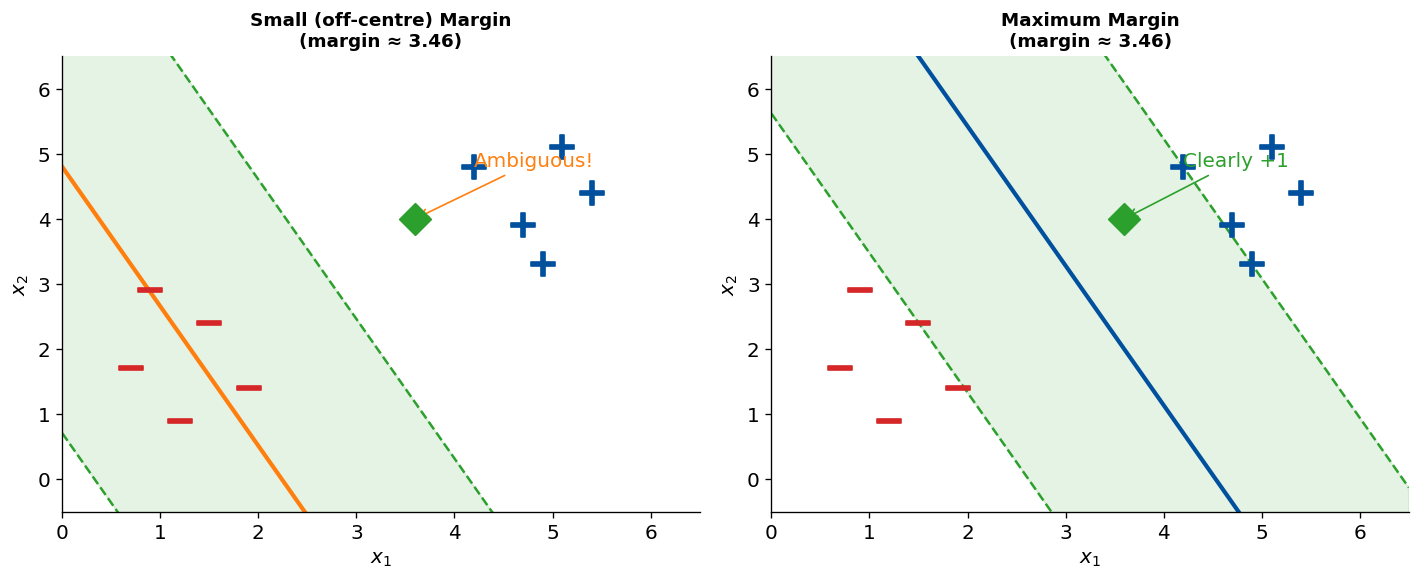

In [3]:
# ============================================================
# 1.3  Small margin vs. maximum margin — robustness demo
# ============================================================
X_pos2 = np.array([[4.2,4.8],[4.7,3.9],[5.1,5.1],[4.9,3.3],[5.4,4.4]])
X_neg2 = np.array([[0.7,1.7],[1.2,0.9],[1.5,2.4],[0.9,2.9],[1.9,1.4]])
X2     = np.vstack([X_pos2, X_neg2])
y2     = np.array([1]*5 + [-1]*5)

# Max-margin SVM (hard)
svm_max = SVC(kernel='linear', C=1e6).fit(X2, y2)
# Off-centred boundary: shift bias toward + class (smaller margin)
svm_off = SVC(kernel='linear', C=1e6).fit(X2, y2)
w_max, b_max = svm_max.coef_[0], svm_max.intercept_[0]

new_point = np.array([[3.6, 4.0]])
margin_new = (w_max @ new_point[0] + b_max) / np.linalg.norm(w_max)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titles = ['Small (off-centre) Margin', 'Maximum Margin']
biases = [b_max + 1.2, b_max]  # shift bias for left panel

for ax, title, bias_offset in zip(axes, titles, [1.2, 0]):
    ax.scatter(*X_pos2.T, marker='$+$', s=200, color=BRAND_BLUE, zorder=3)
    ax.scatter(*X_neg2.T, marker='$-$', s=200, color=RED,        zorder=3)
    ax.scatter(*new_point.T, s=180, color=ACCENT_GREEN, zorder=4, label='New point', marker='D')
    ax.set_xlim(0, 6.5); ax.set_ylim(-0.5, 6.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title(title, fontsize=12, fontweight='bold')

    b_plot = b_max + bias_offset
    color  = ACCENT_ORANGE if bias_offset != 0 else BRAND_BLUE
    plot_line(ax, w_max, b_plot, (0, 6.5), color=color, lw=2.5)
    plot_line(ax, w_max, b_plot, (0, 6.5), offset=-1, color=ACCENT_GREEN, lw=1.5, ls='--')
    plot_line(ax, w_max, b_plot, (0, 6.5), offset=+1, color=ACCENT_GREEN, lw=1.5, ls='--')

    x_fill = np.linspace(0, 6.5, 200)
    y_u = -(w_max[0]*x_fill + b_plot - 1) / w_max[1]
    y_l = -(w_max[0]*x_fill + b_plot + 1) / w_max[1]
    ax.fill_between(x_fill, y_l, y_u, alpha=0.12, color=ACCENT_GREEN)

    # Is the new point inside the margin?
    score = (w_max @ new_point[0] + b_plot) / np.linalg.norm(w_max)
    margin_total = 2 / np.linalg.norm(w_max)
    if bias_offset != 0:
        ax.annotate('Ambiguous!', xy=(3.6, 4.0), xytext=(4.2, 4.8),
                    arrowprops=dict(arrowstyle='->', color=ACCENT_ORANGE), color=ACCENT_ORANGE)
    else:
        ax.annotate('Clearly +1', xy=(3.6, 4.0), xytext=(4.2, 4.8),
                    arrowprops=dict(arrowstyle='->', color=ACCENT_GREEN), color=ACCENT_GREEN)
    ax.set_title(f'{title}\n(margin ≈ {margin_total:.2f})', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_margin_robustness.png', bbox_inches='tight')
plt.show()

---
## Part 2 — Hard-Margin SVM: The Derivation

### 2.1  Decision Rule & Margin Constraints

**Notation:**  
- Training data: $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$, where $y_i \in \{+1, -1\}$  
- Hyperplane: $\mathbf{w}^\top \mathbf{x} + b = 0$  
- Decision rule: $\hat{y} = \text{sign}(\mathbf{w}^\top \mathbf{x} + b)$

By convention we **rescale** $\mathbf{w}$ so that the support vectors satisfy:
$$y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 \quad \forall i$$

The **geometric margin** is then $\gamma = \dfrac{2}{\|\mathbf{w}\|}$.

### 2.2  The Primal Optimisation Problem

Maximise $\gamma = \dfrac{2}{\|\mathbf{w}\|}$ ↔ Minimise $\dfrac{1}{2}\|\mathbf{w}\|^2$:

$$\boxed{\min_{\mathbf{w},b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{s.t.} \quad y_i(\mathbf{w}^\top\mathbf{x}_i + b) \geq 1 \; \forall i}$$

This is a **convex Quadratic Program (QP)** with linear constraints — always has a unique global optimum.

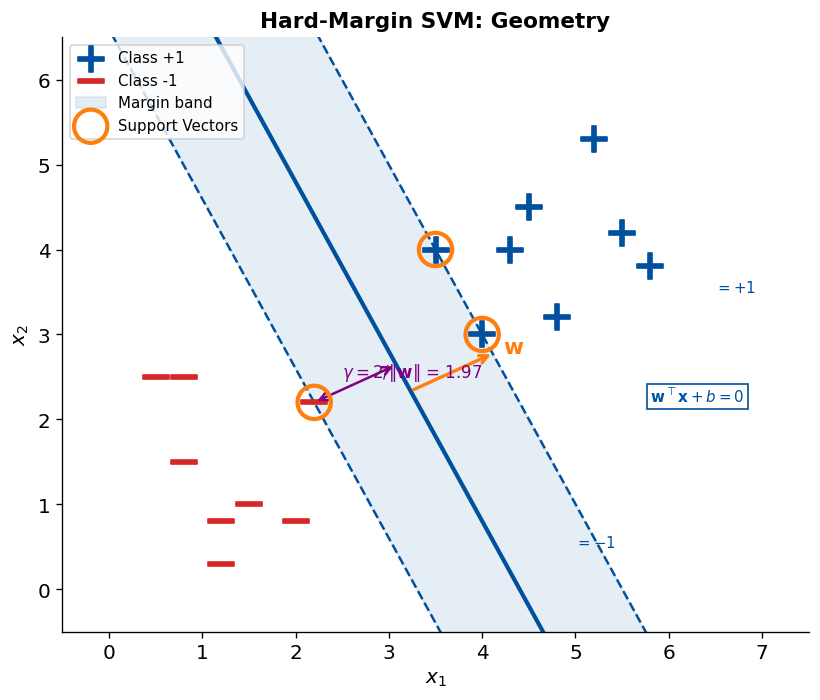

w = [0.90893316 0.45489971]
b = -4.0006
||w|| = 1.0164
Geometric margin = 2/||w|| = 1.9677
Support vectors:
[[2.2 2.2]
 [3.5 4. ]
 [4.  3. ]]


In [4]:
# ============================================================
# 2.3  Visualise the geometry: w vector, margin, support vectors
# ============================================================
svm_hard = SVC(kernel='linear', C=1e9).fit(X_demo, y_demo)
w_h, b_h = svm_hard.coef_[0], svm_hard.intercept_[0]
margin_h = 1.0 / np.linalg.norm(w_h)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(*X_pos.T, marker='$+$', s=250, color=BRAND_BLUE, zorder=3, label='Class +1')
ax.scatter(*X_neg.T, marker='$-$', s=250, color=RED,        zorder=3, label='Class -1')

# Decision boundary and margins
x_range = np.linspace(-0.5, 7.5, 300)
for offset, style, lw in [(0, '-', 2.5), (-1, '--', 1.5), (1, '--', 1.5)]:
    y_line = -(w_h[0]*x_range + b_h + offset) / w_h[1]
    ax.plot(x_range, y_line, color=BRAND_BLUE, lw=lw, ls=style)

y_upper = -(w_h[0]*x_range + b_h - 1) / w_h[1]
y_lower = -(w_h[0]*x_range + b_h + 1) / w_h[1]
ax.fill_between(x_range, y_lower, y_upper, alpha=0.1, color=BRAND_BLUE, label='Margin band')

# Support vectors
sv = svm_hard.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=400, facecolors='none', edgecolors=ACCENT_ORANGE,
           lw=2.5, zorder=5, label='Support Vectors')

# Draw the normal vector w from the midpoint of the decision boundary
mid_x = np.mean(sv[:,0])
mid_y = -(w_h[0]*mid_x + b_h) / w_h[1]
w_norm = w_h / np.linalg.norm(w_h)
ax.annotate('', xy=(mid_x + w_norm[0], mid_y + w_norm[1]),
            xytext=(mid_x, mid_y),
            arrowprops=dict(arrowstyle='->', color=ACCENT_ORANGE, lw=2))
ax.text(mid_x + w_norm[0] + 0.1, mid_y + w_norm[1], '$\mathbf{w}$',
        color=ACCENT_ORANGE, fontsize=13, fontweight='bold')

# Margin width annotation
ax.annotate('', xy=(sv[0,0] + margin_h*w_norm[0], sv[0,1] + margin_h*w_norm[1]),
            xytext=(sv[0,0], sv[0,1]),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
ax.text(sv[0,0] + 0.3, sv[0,1] + 0.3, f'$\\gamma = 2/\|\mathbf{{w}}\|$ = {2*margin_h:.2f}',
        color='purple', fontsize=10)

ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 6.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Hard-Margin SVM: Geometry', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)

# Equation labels
ax.text(5.8, 2.2, r'$\mathbf{w}^\top\mathbf{x}+b=0$', color=BRAND_BLUE, fontsize=9,
        bbox=dict(fc='white', ec=BRAND_BLUE, pad=2))
ax.text(6.5, 3.5, r'$=+1$', color=BRAND_BLUE, fontsize=9)
ax.text(5.0, 0.5, r'$=-1$', color=BRAND_BLUE, fontsize=9)

plt.tight_layout()
plt.savefig('fig3_hard_margin.png', bbox_inches='tight')
plt.show()

print(f'w = {w_h}')
print(f'b = {b_h:.4f}')
print(f'||w|| = {np.linalg.norm(w_h):.4f}')
print(f'Geometric margin = 2/||w|| = {2*margin_h:.4f}')
print(f'Support vectors:\n{sv}')

---
## Part 3 — Dual Problem & Support Vectors

### 3.1  The Lagrangian and Dual Formulation

Introduce Lagrange multipliers $\alpha_i \geq 0$ for each constraint:

$$\mathcal{L}(\mathbf{w}, b, \boldsymbol{\alpha}) = \frac{1}{2}\|\mathbf{w}\|^2 - \sum_{i=1}^n \alpha_i \left[ y_i(\mathbf{w}^\top \mathbf{x}_i + b) - 1 \right]$$

Setting $\partial\mathcal{L}/\partial\mathbf{w} = 0$ and $\partial\mathcal{L}/\partial b = 0$ gives:

$$\mathbf{w}^* = \sum_{i=1}^n \alpha_i y_i \mathbf{x}_i \qquad \sum_{i=1}^n \alpha_i y_i = 0$$

### 3.2  The Dual Problem

Substituting back, the **dual** is:

$$\boxed{\max_{\boldsymbol{\alpha}} \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y_i y_j (\mathbf{x}_i \cdot \mathbf{x}_j) \quad \text{s.t.} \quad \alpha_i \geq 0, \; \sum_i \alpha_i y_i = 0}$$

### 3.3  KKT Conditions & Sparsity

The KKT complementary slackness condition states:
$$\alpha_i \left[ y_i(\mathbf{w}^\top \mathbf{x}_i + b) - 1 \right] = 0$$

Therefore either $\alpha_i = 0$ (point is *not* a support vector) or the point lies **exactly on the margin**.  
**Most $\alpha_i = 0$ → sparse solution!**

### 3.4  Decision Function

$$f(\mathbf{x}) = \text{sign}\!\left(\sum_{i \in \text{SV}} \alpha_i\, y_i\, (\mathbf{x}_i \cdot \mathbf{x}) + b\right)$$

Once trained, the **entire model is stored in the support vectors** — the rest of the data can be discarded.

In [5]:
# ============================================================
# 3.5  Inspect dual variables (alpha) after training
# ============================================================
from sklearn.svm import SVC

# sklearn exposes dual_coef_ = alpha_i * y_i for support vectors
svm_dual = SVC(kernel='linear', C=1e9)
svm_dual.fit(X_demo, y_demo)

sv_indices = svm_dual.support_
dual_coefs = svm_dual.dual_coef_[0]   # alpha_i * y_i
alphas     = np.abs(dual_coefs)        # |alpha_i|

print('=== Dual Solution Analysis ===')
print(f'Total training points   : {len(X_demo)}')
print(f'Support vectors         : {len(sv_indices)}  ({100*len(sv_indices)/len(X_demo):.0f}%)')
print(f'Non-support vectors     : {len(X_demo)-len(sv_indices)}  (alpha_i = 0 by KKT)')
print()
print('Support vector details:')
for idx, sv, a in zip(sv_indices, svm_dual.support_vectors_, alphas):
    y_sv = y_demo[idx]
    print(f'  Index {idx:2d} | x={sv} | y={y_sv:+d} | alpha={a:.4f}')

# Verify: w = sum(alpha_i * y_i * x_i)
w_reconstructed = svm_dual.dual_coef_ @ svm_dual.support_vectors_
print(f'\nVerification: w from dual coefs = {w_reconstructed[0]}')
print(f'              w from svm.coef_  = {svm_dual.coef_[0]}')
print(f'\nKey takeaway: Only {len(sv_indices)} of {len(X_demo)} points define the entire model!')

=== Dual Solution Analysis ===
Total training points   : 16
Support vectors         : 3  (19%)
Non-support vectors     : 13  (alpha_i = 0 by KKT)

Support vector details:
  Index 14 | x=[2.2 2.2] | y=-1 | alpha=0.5165
  Index  0 | x=[3.5 4. ] | y=+1 | alpha=0.0417
  Index  1 | x=[4. 3.] | y=+1 | alpha=0.4749

Verification: w from dual coefs = [0.90893316 0.45489971]
              w from svm.coef_  = [0.90893316 0.45489971]

Key takeaway: Only 3 of 16 points define the entire model!


---
## Part 4 — Soft-Margin SVM

### 4.1  When Data Is Not Linearly Separable

Real data often has **overlapping classes** — the hard-margin SVM becomes infeasible.  
Solution: introduce **slack variables** $\xi_i \geq 0$ to allow constraint violations:

$$y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 - \xi_i$$

**Interpretation:**
- $\xi_i = 0$: correctly classified, outside margin  
- $0 < \xi_i < 1$: inside the margin but on the correct side  
- $\xi_i \geq 1$: **misclassified**

### 4.2  Soft-Margin Primal

$$\boxed{\min_{\mathbf{w}, b, \boldsymbol{\xi}} \; \underbrace{\frac{1}{2}\|\mathbf{w}\|^2}_{\text{max margin}} + C \underbrace{\sum_{i=1}^n \xi_i}_{\text{total slack}}}$$

**The role of C:**
- Large $C$ → penalises violations heavily → narrow margin → risk of overfitting  
- Small $C$ → allows violations → wider margin → risk of underfitting

### 4.3  Hinge Loss Reformulation

Since $\xi_i = \max(0, 1 - y_i f(\mathbf{x}_i))$, the soft-margin SVM is equivalent to:

$$\min_{\mathbf{w}, b} \; \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^n \underbrace{\max(0, 1 - y_i f(\mathbf{x}_i))}_{\text{hinge loss}}$$

**Hinge vs. log loss:** Hinge loss is *exactly zero* for correctly classified points outside the margin → sparsity. Log loss is always $> 0$.

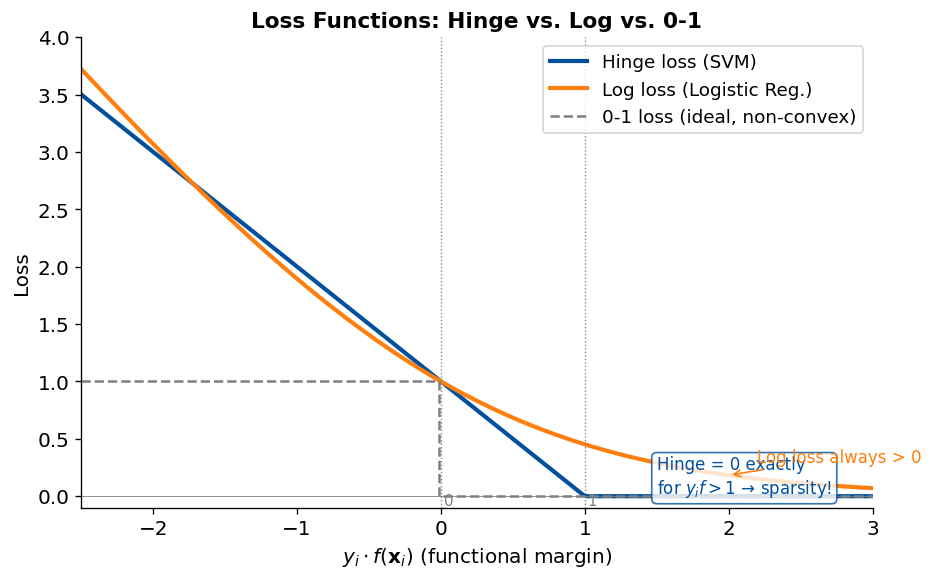

In [6]:
# ============================================================
# 4.4  Visualise hinge loss vs. log loss vs. 0-1 loss
# ============================================================
yf = np.linspace(-2.5, 3, 300)   # y_i * f(x_i)

hinge_loss   = np.maximum(0, 1 - yf)
log_loss_val = np.log(1 + np.exp(-yf)) / np.log(2)  # log base 2 for scale
zero_one     = (yf < 0).astype(float)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(yf, hinge_loss, color=BRAND_BLUE, lw=2.5, label='Hinge loss (SVM)')
ax.plot(yf, log_loss_val, color=ACCENT_ORANGE, lw=2.5, label='Log loss (Logistic Reg.)')
ax.step(yf, zero_one, color='grey', lw=1.5, ls='--', label='0-1 loss (ideal, non-convex)')

ax.axvline(x=1, color='grey', lw=0.8, ls=':')
ax.axvline(x=0, color='grey', lw=0.8, ls=':')
ax.axhline(y=0, color='grey', lw=0.5)

ax.annotate('Hinge = 0 exactly\nfor $y_if > 1$ → sparsity!',
            xy=(1.5, 0.03), fontsize=10, color=BRAND_BLUE,
            bbox=dict(boxstyle='round', fc='white', ec=BRAND_BLUE, alpha=0.8))
ax.annotate('Log loss always > 0',
            xy=(2.0, log_loss_val[yf.searchsorted(2.0)]),
            xytext=(2.2, 0.3),
            fontsize=10, color=ACCENT_ORANGE,
            arrowprops=dict(arrowstyle='->', color=ACCENT_ORANGE))

ax.set_xlabel('$y_i \\cdot f(\\mathbf{x}_i)$ (functional margin)', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Loss Functions: Hinge vs. Log vs. 0-1', fontsize=13, fontweight='bold')
ax.set_ylim(-0.1, 4)
ax.set_xlim(-2.5, 3)
ax.legend(fontsize=11)
ax.text(1.02, -0.08, '1', fontsize=9, color='grey')
ax.text(0.02, -0.08, '0', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('fig4_hinge_loss.png', bbox_inches='tight')
plt.show()

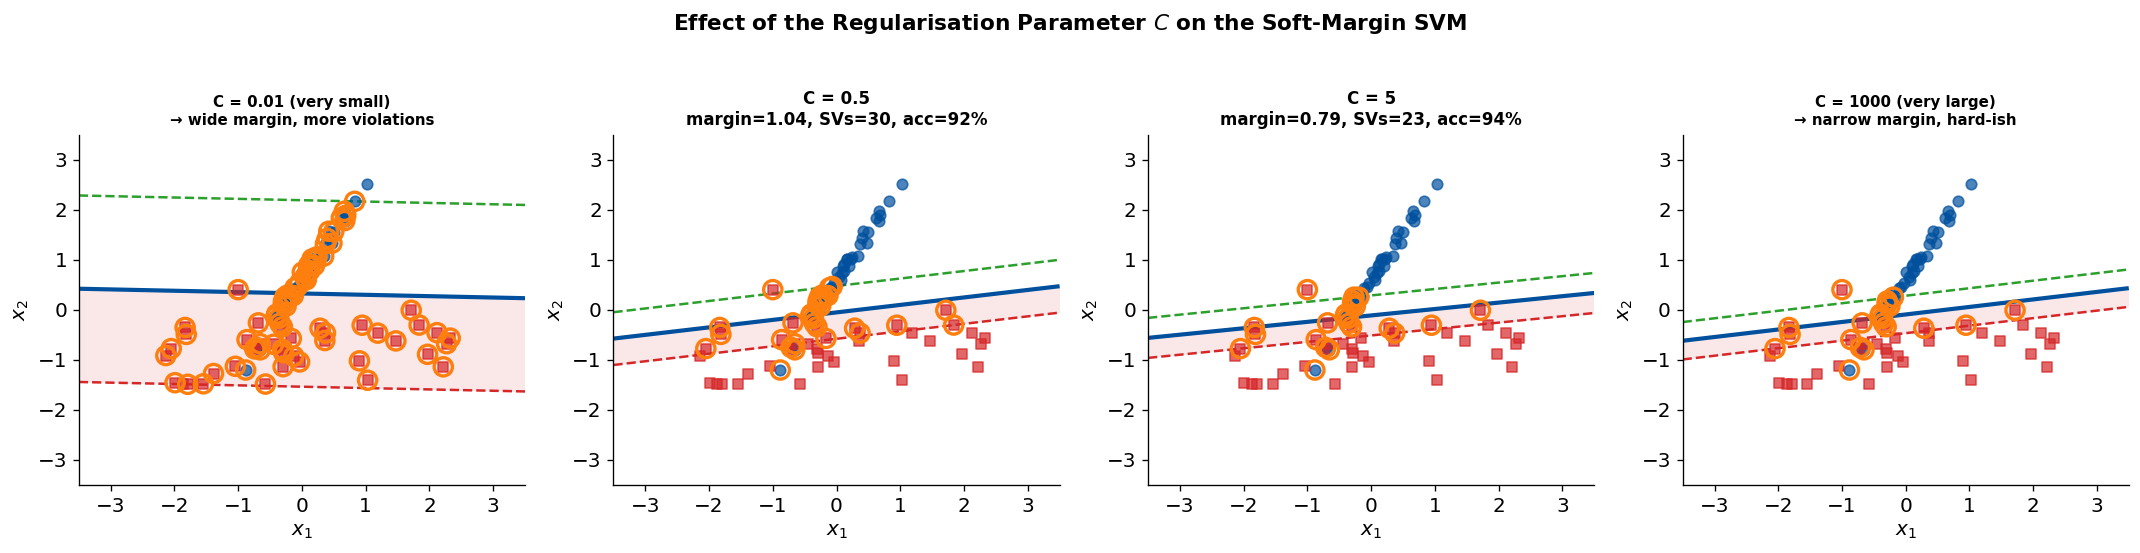

Bias-variance trade-off summary:
         C |   Margin |  #SVs |  Train acc
---------------------------------------------
      0.01 |    3.728 |    78 |      82.5%
       0.5 |    1.044 |    30 |      92.5%
         5 |    0.794 |    23 |      93.8%
      1000 |    0.740 |    21 |      92.5%


In [7]:
# ============================================================
# 4.5  Effect of C on the decision boundary
# ============================================================
np.random.seed(42)
X_noisy, y_noisy = make_classification(
    n_samples=80, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=0.8, random_state=42
)
y_noisy = np.where(y_noisy == 0, -1, 1)
scaler = StandardScaler()
X_noisy = scaler.fit_transform(X_noisy)

C_values = [0.01, 0.5, 5, 1000]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 300), np.linspace(-3.5, 3.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, C in zip(axes, C_values):
    svm = SVC(kernel='linear', C=C).fit(X_noisy, y_noisy)
    margin_width = 2 / np.linalg.norm(svm.coef_[0])
    n_sv = len(svm.support_)

    Z = svm.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.1,
                colors=[RED, 'white', BRAND_BLUE])
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=[RED, BRAND_BLUE, ACCENT_GREEN],
               linestyles=['--', '-', '--'], linewidths=[1.5, 2.5, 1.5])

    ax.scatter(X_noisy[y_noisy==1,0],  X_noisy[y_noisy==1,1],  marker='o', s=40,
               color=BRAND_BLUE, alpha=0.7, zorder=3)
    ax.scatter(X_noisy[y_noisy==-1,0], X_noisy[y_noisy==-1,1], marker='s', s=40,
               color=RED, alpha=0.7, zorder=3)
    ax.scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1],
               s=120, facecolors='none', edgecolors=ACCENT_ORANGE, lw=2, zorder=5)

    acc = np.mean(svm.predict(X_noisy) == y_noisy)
    ax.set_title(f'C = {C}\nmargin={margin_width:.2f}, SVs={n_sv}, acc={acc:.0%}',
                 fontsize=10, fontweight='bold')
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

axes[0].set_title(f'C = {C_values[0]} (very small)\n→ wide margin, more violations', fontsize=9, fontweight='bold')
axes[-1].set_title(f'C = {C_values[-1]} (very large)\n→ narrow margin, hard-ish', fontsize=9, fontweight='bold')

fig.suptitle('Effect of the Regularisation Parameter $C$ on the Soft-Margin SVM',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_C_effect.png', bbox_inches='tight')
plt.show()

print('Bias-variance trade-off summary:')
print(f'{"C":>10} | {"Margin":>8} | {"#SVs":>5} | {"Train acc":>10}')
print('-'*45)
for C in C_values:
    s = SVC(kernel='linear', C=C).fit(X_noisy, y_noisy)
    m = 2 / np.linalg.norm(s.coef_[0])
    a = np.mean(s.predict(X_noisy) == y_noisy)
    print(f'{C:>10} | {m:>8.3f} | {len(s.support_):>5d} | {a:>10.1%}')

---
## Part 5 — The Kernel Trick

### 5.1  When Linear Is Not Enough

For **non-linearly separable** data, map $\mathbf{x} \in \mathbb{R}^p$ to a higher-dimensional **feature space** via $\phi: \mathbb{R}^p \to \mathbb{R}^P$ where $P \gg p$. In the new space the data may become linearly separable.

### 5.2  The Key Insight

The dual SVM only uses dot products $\mathbf{x}_i \cdot \mathbf{x}_j$.  
After mapping: replace every dot product $\phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j) \to K(\mathbf{x}_i, \mathbf{x}_j)$.

**If $K$ can be computed directly** (without ever computing $\phi$), we get nonlinear boundaries at the **cost of a linear SVM**!

### 5.3  Common Kernels

| Kernel | Formula | When to use |
|--------|---------|-------------|
| Linear | $K(\mathbf{x},\mathbf{z}) = \mathbf{x}\cdot\mathbf{z}$ | Linearly separable, high-dimensional ($p > n$) |
| Polynomial | $K(\mathbf{x},\mathbf{z}) = (\mathbf{x}\cdot\mathbf{z} + c)^d$ | Polynomial relationships |
| RBF (Gaussian) | $K(\mathbf{x},\mathbf{z}) = e^{-\gamma\|\mathbf{x}-\mathbf{z}\|^2}$ | General-purpose, maps to $\infty$-dim space |
| Sigmoid | $K(\mathbf{x},\mathbf{z}) = \tanh(\kappa\,\mathbf{x}\cdot\mathbf{z} + c)$ | Specific settings |

### 5.4  Worked Example: Polynomial Kernel

For $\mathbf{x} = (1,2)$, $\mathbf{z} = (3,4)$, $K(\mathbf{x},\mathbf{z}) = (\mathbf{x}\cdot\mathbf{z}+1)^2$:

- **Kernel (cheap):** $K = (1\cdot3 + 2\cdot4 + 1)^2 = 12^2 = 144$
- **Explicit $\phi$ (expensive):** $\phi(\mathbf{x}) \cdot \phi(\mathbf{z}) = 9+64+48+6+16+1 = 144$ ✓

In [8]:
# ============================================================
# 5.5  Polynomial kernel: verify the worked example numerically
# ============================================================
import numpy as np

x = np.array([1., 2.])
z = np.array([3., 4.])

# Method 1: kernel function directly
K_direct = (np.dot(x, z) + 1)**2

# Method 2: explicit feature map phi(x) for degree-2 polynomial kernel
def phi_poly2(v):
    x1, x2 = v
    return np.array([x1**2, x2**2, np.sqrt(2)*x1*x2,
                     np.sqrt(2)*x1, np.sqrt(2)*x2, 1.])

phi_x = phi_poly2(x)
phi_z = phi_poly2(z)
K_explicit = np.dot(phi_x, phi_z)

print('=== Polynomial Kernel Verification ===')
print(f'x = {x}, z = {z}')
print(f'x·z = {np.dot(x,z)}')
print(f'K(x,z) = (x·z + 1)^2 = ({np.dot(x,z)} + 1)^2 = {K_direct}')
print()
print(f'phi(x) = {phi_x.round(4)}')
print(f'phi(z) = {phi_z.round(4)}')
print(f'phi(x)·phi(z) = {K_explicit:.4f}')
print()
print(f'Match: {np.isclose(K_direct, K_explicit)}')
print(f'\nKey insight: 1 scalar product in R^2 vs. 6-dim dot product → same result!')
print(f'For RBF kernel, phi has INFINITE dimensions!')

=== Polynomial Kernel Verification ===
x = [1. 2.], z = [3. 4.]
x·z = 11.0
K(x,z) = (x·z + 1)^2 = (11.0 + 1)^2 = 144.0

phi(x) = [1.     4.     2.8284 1.4142 2.8284 1.    ]
phi(z) = [ 9.     16.     16.9706  4.2426  5.6569  1.    ]
phi(x)·phi(z) = 144.0000

Match: True

Key insight: 1 scalar product in R^2 vs. 6-dim dot product → same result!
For RBF kernel, phi has INFINITE dimensions!


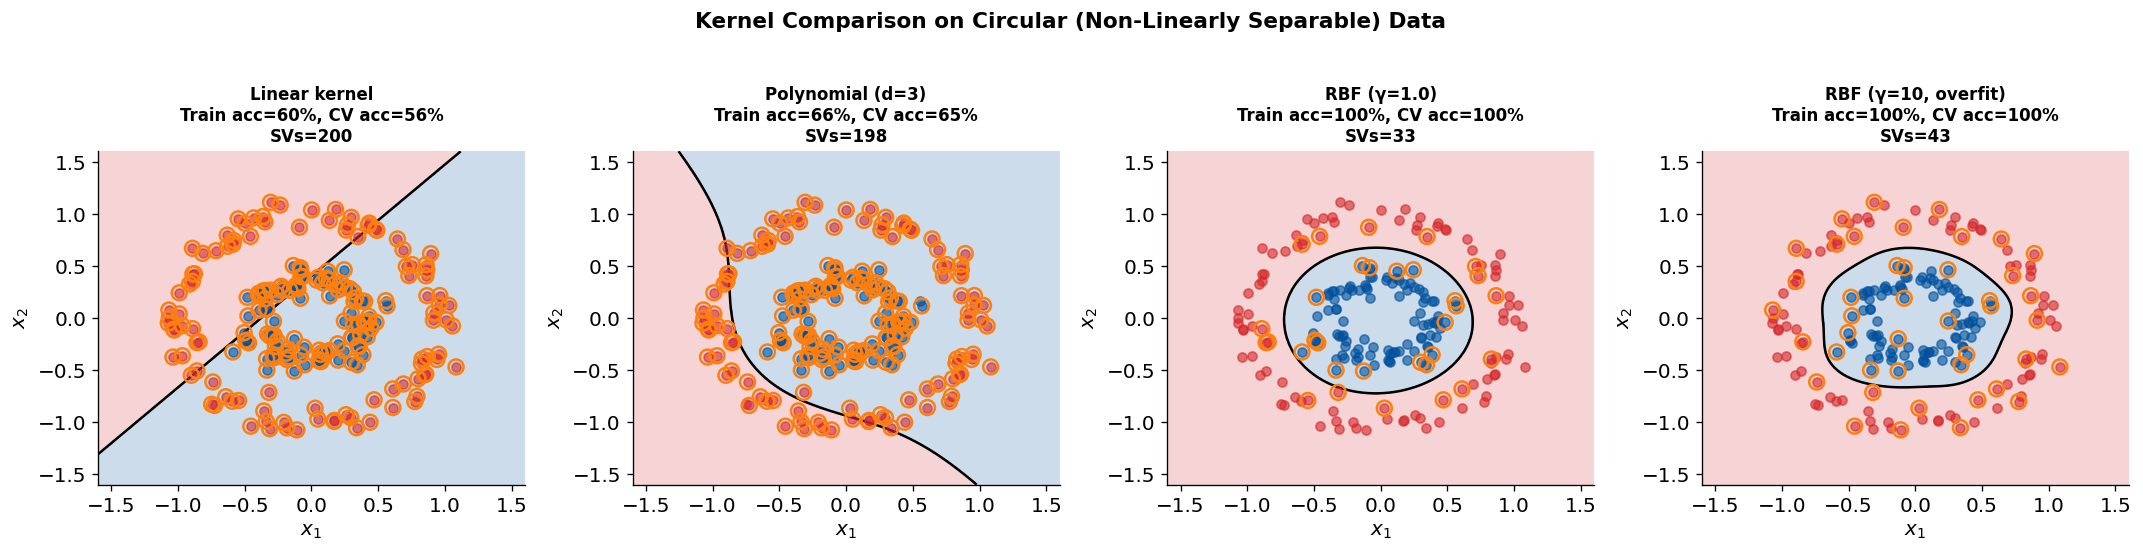

In [9]:
# ============================================================
# 5.6  Kernel comparison on a circular dataset (like the lecture slide)
# ============================================================
np.random.seed(7)
X_circ, y_circ = make_circles(n_samples=200, noise=0.08, factor=0.4, random_state=7)
y_circ = np.where(y_circ == 0, -1, 1)

kernels = [
    ('linear',  {'C': 1.0},             'Linear kernel'),
    ('poly',    {'C': 1.0, 'degree': 3},'Polynomial (d=3)'),
    ('rbf',     {'C': 1.0, 'gamma': 1.0},'RBF (γ=1.0)'),
    ('rbf',     {'C': 1.0, 'gamma': 10.0},'RBF (γ=10, overfit)'),
]

xx, yy = np.meshgrid(np.linspace(-1.6, 1.6, 300), np.linspace(-1.6, 1.6, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, (kernel, params, title) in zip(axes, kernels):
    svm_k = SVC(kernel=kernel, **params).fit(X_circ, y_circ)
    Z = svm_k.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2,
                cmap=ListedColormap([RED, BRAND_BLUE]))
    ax.contour(xx, yy, svm_k.decision_function(grid).reshape(xx.shape),
               levels=[0], colors='black', lw=2)

    ax.scatter(X_circ[y_circ==1,0],  X_circ[y_circ==1,1],
               s=30, color=BRAND_BLUE, alpha=0.6, zorder=3)
    ax.scatter(X_circ[y_circ==-1,0], X_circ[y_circ==-1,1],
               s=30, color=RED, alpha=0.6, zorder=3)
    ax.scatter(svm_k.support_vectors_[:,0], svm_k.support_vectors_[:,1],
               s=80, facecolors='none', edgecolors=ACCENT_ORANGE, lw=1.5, zorder=5)

    acc = np.mean(svm_k.predict(X_circ) == y_circ)
    cv  = cross_val_score(svm_k, X_circ, y_circ, cv=5).mean()
    ax.set_title(f'{title}\nTrain acc={acc:.0%}, CV acc={cv:.0%}\nSVs={len(svm_k.support_)}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)

fig.suptitle('Kernel Comparison on Circular (Non-Linearly Separable) Data',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_kernels.png', bbox_inches='tight')
plt.show()

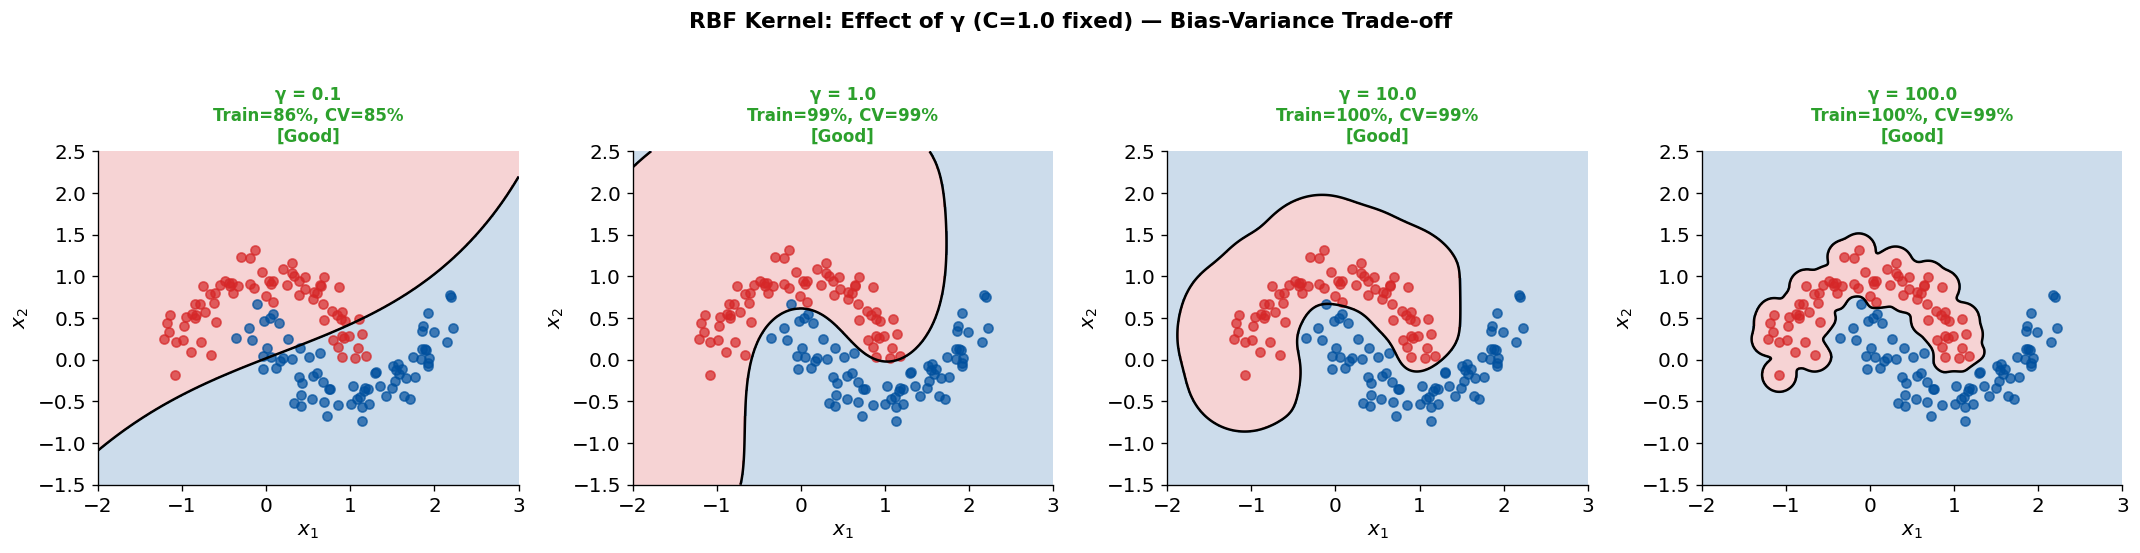

In [10]:
# ============================================================
# 5.7  Effect of RBF gamma: underfitting vs. overfitting
# ============================================================
np.random.seed(42)
X_moons, y_moons = make_moons(n_samples=150, noise=0.15, random_state=42)
y_moons = np.where(y_moons == 0, -1, 1)

gamma_values = [0.1, 1.0, 10.0, 100.0]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

xx_m, yy_m = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.5, 2.5, 300))
grid_m = np.c_[xx_m.ravel(), yy_m.ravel()]

for ax, gamma in zip(axes, gamma_values):
    svm_g = SVC(kernel='rbf', C=1.0, gamma=gamma).fit(X_moons, y_moons)
    Z = svm_g.predict(grid_m).reshape(xx_m.shape)

    ax.contourf(xx_m, yy_m, Z, alpha=0.2, cmap=ListedColormap([RED, BRAND_BLUE]))
    ax.contour(xx_m, yy_m, svm_g.decision_function(grid_m).reshape(xx_m.shape),
               levels=[0], colors='black', lw=2)

    ax.scatter(X_moons[y_moons==1,0],  X_moons[y_moons==1,1],  s=30, color=BRAND_BLUE, alpha=0.7)
    ax.scatter(X_moons[y_moons==-1,0], X_moons[y_moons==-1,1], s=30, color=RED, alpha=0.7)

    train_acc = np.mean(svm_g.predict(X_moons) == y_moons)
    cv_acc    = cross_val_score(SVC(kernel='rbf', C=1.0, gamma=gamma),
                                X_moons, y_moons, cv=5).mean()

    diagnosis = 'Underfit' if cv_acc < 0.80 else ('Overfit' if train_acc - cv_acc > 0.1 else 'Good')
    color_t    = RED if diagnosis != 'Good' else ACCENT_GREEN

    ax.set_title(f'γ = {gamma}\nTrain={train_acc:.0%}, CV={cv_acc:.0%}\n[{diagnosis}]',
                 fontsize=10, fontweight='bold', color=color_t)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

fig.suptitle('RBF Kernel: Effect of γ (C=1.0 fixed) — Bias-Variance Trade-off',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_gamma_effect.png', bbox_inches='tight')
plt.show()

---
## Part 6 — Practical Considerations

### 6.1  Feature Scaling Is Essential

SVM uses **Euclidean distances** in the kernel computation.  
Features with larger magnitudes **dominate** the distance → biased margin.  
**Always standardise:** $x_j \leftarrow \dfrac{x_j - \mu_j}{\sigma_j}$

### 6.2  Hyperparameter Tuning: Grid Search + Cross-Validation

For RBF kernel, tune $(C, \gamma)$ jointly:  
- $C \in \{10^{-2}, 10^{-1}, 1, 10, 100, 1000\}$  
- $\gamma \in \{10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1, 10\}$

### 6.3  Multi-Class Strategies

SVM is inherently binary. For $K$ classes:
- **One-vs-Rest (OvR):** Train $K$ classifiers. Each: class $k$ vs. all others.
- **One-vs-One (OvO):** Train $\binom{K}{2}$ classifiers. Each on 2 classes. Majority vote. ← *scikit-learn default*

### 6.4  When to Use SVMs

✅ **Strengths:** Effective in high dimensions, works when $n > m$, memory-efficient, versatile via kernels  
❌ **Limitations:** Slow for large $n$ ($O(n^2)$–$O(n^3)$), no native probabilities, sensitive to scaling  
🎯 **Sweet spot:** moderate $m$ ($10^2$–$10^4$), high $n$, complex boundaries, clean labels

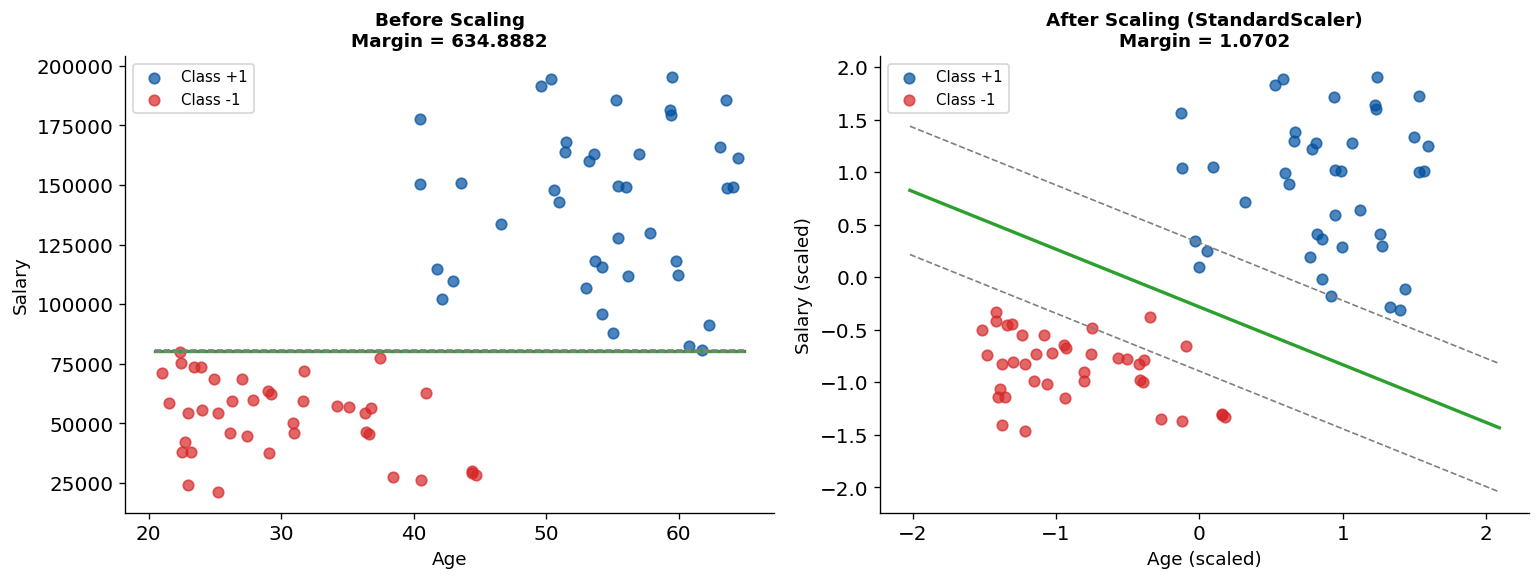

Without scaling: margin is dominated by high-magnitude salary feature
With scaling:    both features contribute equally to the margin


In [11]:
# ============================================================
# 6.1  Feature scaling: before vs. after
# ============================================================
np.random.seed(0)
n = 80
# Unscaled: Age (20–65) and Salary (20000–200000)
age_p = np.random.uniform(40, 65, n//2)
age_n = np.random.uniform(20, 45, n//2)
sal_p = np.random.uniform(80000, 200000, n//2)
sal_n = np.random.uniform(20000, 80000, n//2)

X_unscaled = np.vstack([
    np.c_[age_p, sal_p],
    np.c_[age_n, sal_n]
])
y_scale = np.array([1]*(n//2) + [-1]*(n//2))

scaler_s = StandardScaler()
X_scaled = scaler_s.fit_transform(X_unscaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, X_plot, title, xlabel, ylabel in [
    (axes[0], X_unscaled, 'Before Scaling', 'Age', 'Salary'),
    (axes[1], X_scaled,   'After Scaling (StandardScaler)', 'Age (scaled)', 'Salary (scaled)')
]:
    svm_s = SVC(kernel='linear', C=1.0).fit(X_plot, y_scale)
    w_s, b_s = svm_s.coef_[0], svm_s.intercept_[0]
    margin_s = 2 / np.linalg.norm(w_s)

    ax.scatter(X_plot[y_scale==1,0],  X_plot[y_scale==1,1],  s=40, color=BRAND_BLUE, alpha=0.7, label='Class +1')
    ax.scatter(X_plot[y_scale==-1,0], X_plot[y_scale==-1,1], s=40, color=RED, alpha=0.7, label='Class -1')

    x_min, x_max = X_plot[:,0].min()-0.5, X_plot[:,0].max()+0.5
    x_rng = np.linspace(x_min, x_max, 300)
    for offset, ls in [(0, '-'), (-1, '--'), (1, '--')]:
        y_l = -(w_s[0]*x_rng + b_s + offset) / w_s[1]
        ax.plot(x_rng, y_l, color=ACCENT_GREEN if offset==0 else 'grey', lw=2 if offset==0 else 1, ls=ls)

    ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{title}\nMargin = {margin_s:.4f}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig8_scaling.png', bbox_inches='tight')
plt.show()

print('Without scaling: margin is dominated by high-magnitude salary feature')
print('With scaling:    both features contribute equally to the margin')

=== Grid Search Results ===
Best parameters : {'svm__C': 10, 'svm__gamma': 10}
Best CV accuracy: 0.9467


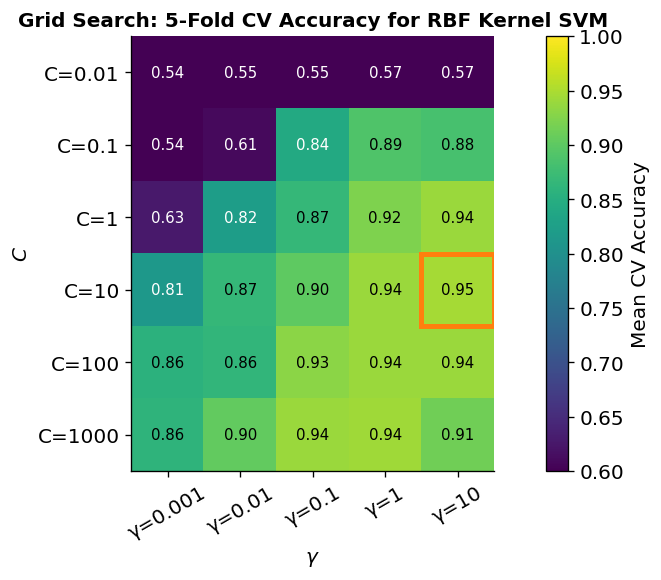

In [12]:
# ============================================================
# 6.2  Grid search for (C, gamma) — the right way
# ============================================================
np.random.seed(99)
X_gs, y_gs = make_classification(
    n_samples=300, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=0.7, random_state=99
)
y_gs = np.where(y_gs == 0, -1, 1)

# Build a proper pipeline: scale → SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf'))
])

param_grid = {
    'svm__C':     [0.01, 0.1, 1, 10, 100, 1000],
    'svm__gamma': [0.001, 0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy',
                           n_jobs=-1, verbose=0)
grid_search.fit(X_gs, y_gs)

print('=== Grid Search Results ===')
print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

# Visualise the grid search heat map
results = grid_search.cv_results_
scores = results['mean_test_score'].reshape(len(param_grid['svm__C']),
                                             len(param_grid['svm__gamma']))

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(scores, interpolation='nearest', cmap='viridis', vmin=0.6, vmax=1.0)
plt.colorbar(im, ax=ax, label='Mean CV Accuracy')

ax.set_xticks(range(len(param_grid['svm__gamma'])))
ax.set_yticks(range(len(param_grid['svm__C'])))
ax.set_xticklabels([f'γ={g}' for g in param_grid['svm__gamma']], rotation=30)
ax.set_yticklabels([f'C={c}' for c in param_grid['svm__C']])
ax.set_xlabel('$\\gamma$', fontsize=12); ax.set_ylabel('$C$', fontsize=12)
ax.set_title('Grid Search: 5-Fold CV Accuracy for RBF Kernel SVM', fontsize=12, fontweight='bold')

for i in range(len(param_grid['svm__C'])):
    for j in range(len(param_grid['svm__gamma'])):
        ax.text(j, i, f'{scores[i,j]:.2f}', ha='center', va='center',
                color='white' if scores[i,j] < 0.85 else 'black', fontsize=9)

# Mark the best
best_C_idx = param_grid['svm__C'].index(grid_search.best_params_['svm__C'])
best_g_idx = param_grid['svm__gamma'].index(grid_search.best_params_['svm__gamma'])
ax.add_patch(plt.Rectangle((best_g_idx-0.5, best_C_idx-0.5), 1, 1,
                             fill=False, edgecolor=ACCENT_ORANGE, lw=3))

plt.tight_layout()
plt.savefig('fig9_gridsearch.png', bbox_inches='tight')
plt.show()

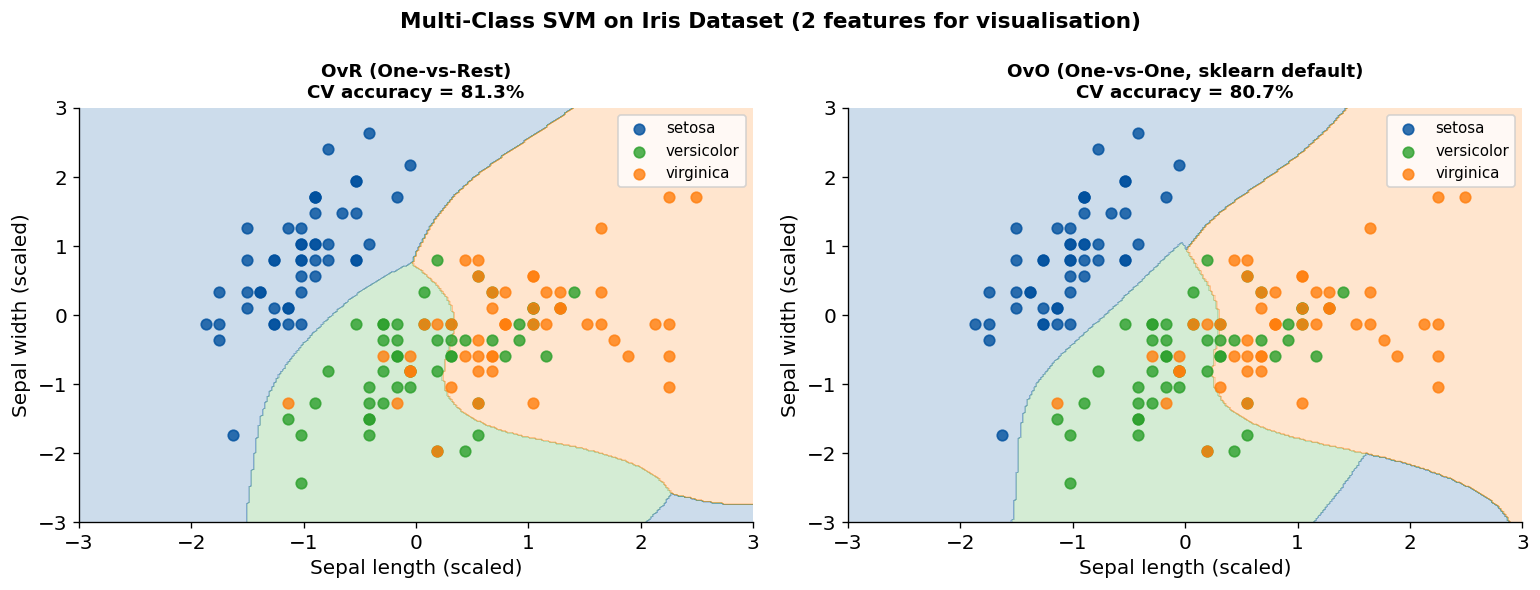

OvR (One-vs-Rest)                            : CV acc = 0.9800
OvO (One-vs-One, sklearn default)            : CV acc = 0.9800


In [13]:
# ============================================================
# 6.3  Multi-class SVM: One-vs-Rest vs. One-vs-One
# ============================================================
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import ConfusionMatrixDisplay

iris = load_iris()
X_iris = iris.data[:, :2]   # use first 2 features for 2D visualisation
y_iris = iris.target

scaler_iris = StandardScaler()
X_iris_sc   = scaler_iris.fit_transform(X_iris)

classifiers = {
    'OvR (One-vs-Rest)': OneVsRestClassifier(SVC(kernel='rbf', C=5, gamma='scale')),
    'OvO (One-vs-One, sklearn default)': SVC(kernel='rbf', C=5, gamma='scale'),
}

xx_i, yy_i = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
grid_i = np.c_[xx_i.ravel(), yy_i.ravel()]

colors_iris = [BRAND_BLUE, ACCENT_GREEN, ACCENT_ORANGE]
class_names = iris.target_names

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, clf) in zip(axes, classifiers.items()):
    clf.fit(X_iris_sc, y_iris)
    Z = clf.predict(grid_i).reshape(xx_i.shape)

    ax.contourf(xx_i, yy_i, Z, alpha=0.2,
                cmap=ListedColormap(colors_iris))
    for k, (cn, col) in enumerate(zip(class_names, colors_iris)):
        mask = y_iris == k
        ax.scatter(X_iris_sc[mask,0], X_iris_sc[mask,1], s=40,
                   color=col, alpha=0.8, label=cn, zorder=3)

    cv_acc = cross_val_score(clf, X_iris_sc, y_iris, cv=5).mean()
    ax.set_title(f'{name}\nCV accuracy = {cv_acc:.1%}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Sepal length (scaled)'); ax.set_ylabel('Sepal width (scaled)')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

fig.suptitle('Multi-Class SVM on Iris Dataset (2 features for visualisation)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_multiclass.png', bbox_inches='tight')
plt.show()

# Full 4-feature evaluation
X_full = scaler_iris.fit_transform(iris.data)
for name, clf in classifiers.items():
    acc = cross_val_score(clf, X_full, y_iris, cv=5).mean()
    print(f'{name:45s}: CV acc = {acc:.4f}')

---
## Part 7 — Full Pipeline: End-to-End SVM Workflow

Best practice: always use a **scikit-learn Pipeline** so that the scaler is fitted only on training data and applied to test data — preventing **data leakage**.

=== Final Pipeline Evaluation ===
Best params  : {'svm__C': 1, 'svm__gamma': 1}
Best CV acc  : 0.9633
Test accuracy: 0.9700

              precision    recall  f1-score   support

    Class -1       0.98      0.96      0.97        53
    Class +1       0.96      0.98      0.97        47

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



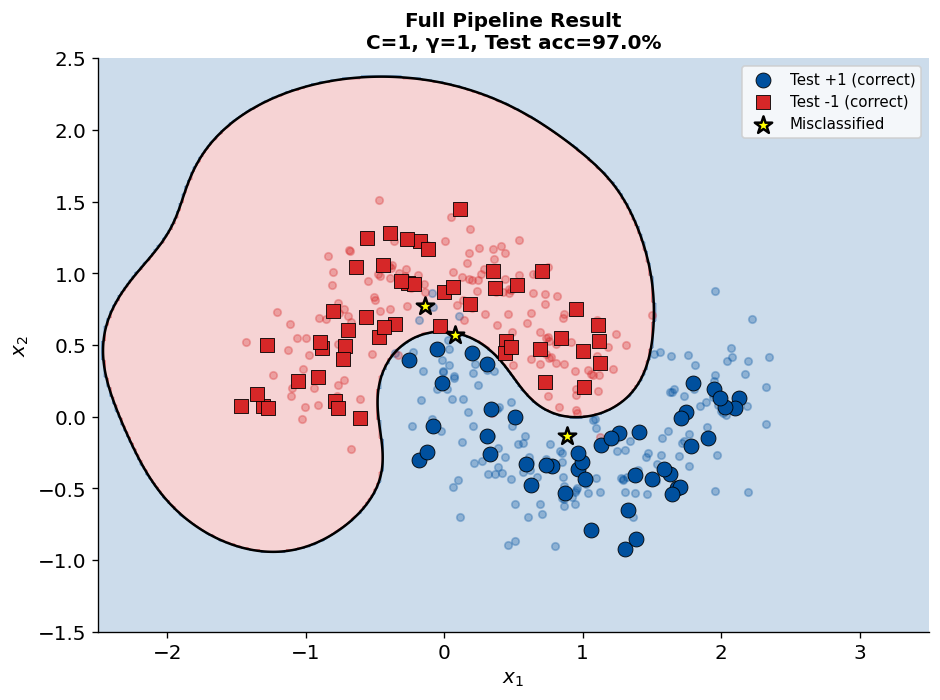

In [14]:
# ============================================================
# 7.1  Full pipeline: split → scale → tune → evaluate
# ============================================================
from sklearn.model_selection import train_test_split

np.random.seed(2026)
X_full, y_full = make_moons(n_samples=400, noise=0.2, random_state=2026)
y_full = np.where(y_full == 0, -1, 1)

X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.25, random_state=42)

# Build pipeline
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', probability=True))
])

# Tune
param_grid_pipe = {
    'svm__C':     [0.1, 1, 10, 100],
    'svm__gamma': [0.01, 0.1, 1, 10]
}
gs = GridSearchCV(svm_pipe, param_grid_pipe, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X_tr, y_tr)

best_pipe = gs.best_estimator_
y_pred    = best_pipe.predict(X_te)

print('=== Final Pipeline Evaluation ===')
print(f'Best params  : {gs.best_params_}')
print(f'Best CV acc  : {gs.best_score_:.4f}')
print(f'Test accuracy: {np.mean(y_pred == y_te):.4f}')
print()
print(classification_report(y_te, y_pred, target_names=['Class -1', 'Class +1']))

# Visualise decision boundary on test set
xx_p, yy_p = np.meshgrid(np.linspace(-2.5, 3.5, 300), np.linspace(-1.5, 2.5, 300))
grid_p = np.c_[xx_p.ravel(), yy_p.ravel()]
Z_p = best_pipe.predict(grid_p).reshape(xx_p.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx_p, yy_p, Z_p, alpha=0.2, cmap=ListedColormap([RED, BRAND_BLUE]))
ax.contour(xx_p, yy_p, best_pipe.decision_function(grid_p).reshape(xx_p.shape),
           levels=[0], colors='black', lw=2)

# Training points (small)
ax.scatter(X_tr[y_tr==1,0],  X_tr[y_tr==1,1],  s=20, color=BRAND_BLUE, alpha=0.3)
ax.scatter(X_tr[y_tr==-1,0], X_tr[y_tr==-1,1], s=20, color=RED, alpha=0.3)
# Test points (larger, with wrong predictions highlighted)
correct = y_pred == y_te
ax.scatter(X_te[correct & (y_te==1),0],  X_te[correct & (y_te==1),1],
           s=80, color=BRAND_BLUE, edgecolors='black', lw=0.5, zorder=5, label='Test +1 (correct)')
ax.scatter(X_te[correct & (y_te==-1),0], X_te[correct & (y_te==-1),1],
           s=80, color=RED, marker='s', edgecolors='black', lw=0.5, zorder=5, label='Test -1 (correct)')
ax.scatter(X_te[~correct,0], X_te[~correct,1],
           s=120, color='yellow', edgecolors='black', lw=1.5, zorder=6, label='Misclassified', marker='*')

ax.set_xlabel('$x_1$', fontsize=12); ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title(f'Full Pipeline Result\nC={gs.best_params_["svm__C"]}, '
             f'γ={gs.best_params_["svm__gamma"]}, Test acc={np.mean(correct):.1%}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig11_full_pipeline.png', bbox_inches='tight')
plt.show()

---
## Part 8 — SVM in the TTK4260 Course Landscape

| Method | Type | Loss/Objective | Solution | Key Property |
|--------|------|---------------|----------|--------------|
| Linear Reg. | Regression | MSE (Gaussian MLE) | Closed-form | All points contribute |
| Logistic Reg. | Classification | Cross-entropy (Bernoulli MLE) | Iterative | Probabilistic output |
| **SVM** | **Classification** | **Hinge + margin** | **QP (sparse)** | **Only SVs matter** |
| PCA | Dim. reduction | Max. variance | Eigenvalue | Unsupervised |
| PLSR | Regression | Max. covariance | NIPALS | Handles $p \gg n$ |

**Connections:**
- **PCA/PLSR** can be used for feature reduction *before* SVM
- **t-SNE** can visualise SVM decision regions in 2D
- **Kernel PCA** uses the same kernel trick — a deep connection

=== Digits Dataset (64 features, 10 classes) ===
Raw SVM (64 features) : CV accuracy = 0.9510
PCA(40) + SVM         : CV accuracy = 0.9494
Feature reduction     : 64 → 40 dims (38% reduction)



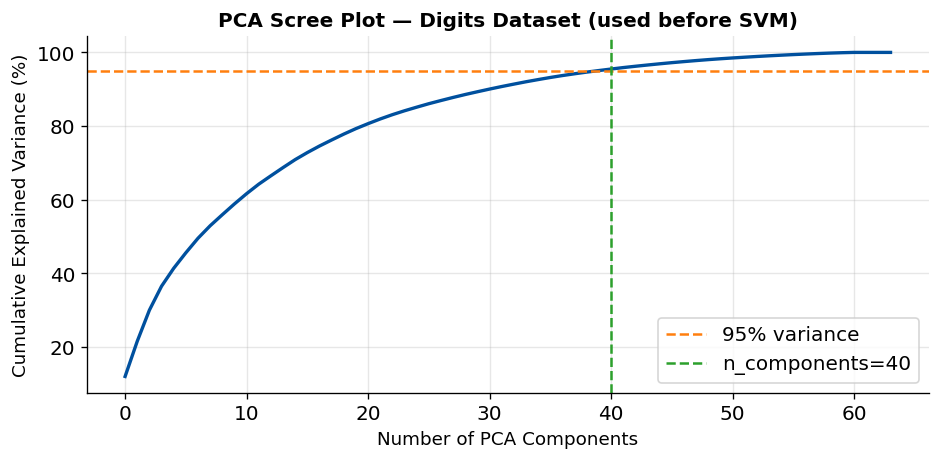

In [15]:
# ============================================================
# 8.1  PCA → SVM pipeline (common practical pattern)
# ============================================================
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

digits = load_digits()
X_dig, y_dig = digits.data, digits.target

# Compare: raw SVM vs. PCA+SVM
pipe_raw  = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf', C=10, gamma='scale'))])
pipe_pca  = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=40)),
                       ('svm', SVC(kernel='rbf', C=10, gamma='scale'))])

cv_raw = cross_val_score(pipe_raw, X_dig, y_dig, cv=5, scoring='accuracy').mean()
cv_pca = cross_val_score(pipe_pca, X_dig, y_dig, cv=5, scoring='accuracy').mean()

print('=== Digits Dataset (64 features, 10 classes) ===')
print(f'Raw SVM (64 features) : CV accuracy = {cv_raw:.4f}')
print(f'PCA(40) + SVM         : CV accuracy = {cv_pca:.4f}')
print(f'Feature reduction     : 64 → 40 dims ({100*(1-40/64):.0f}% reduction)')
print()

# Visualise PCA variance explained
sc = StandardScaler()
X_sc_dig = sc.fit_transform(X_dig)
pca_full = PCA().fit(X_sc_dig)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.cumsum(pca_full.explained_variance_ratio_)*100,
        color=BRAND_BLUE, lw=2)
ax.axhline(y=95, color=ACCENT_ORANGE, ls='--', label='95% variance')
ax.axvline(x=40, color=ACCENT_GREEN, ls='--', label='n_components=40')
ax.set_xlabel('Number of PCA Components', fontsize=11)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
ax.set_title('PCA Scree Plot — Digits Dataset (used before SVM)', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig12_pca_svm.png', bbox_inches='tight')
plt.show()

---
## Part 9 — Interactive Exercises

Use the interactive widget below to explore how **C** and **γ** affect the SVM decision boundary in real time.

In [ ]:
# ============================================================
# 9.1  Interactive widget: explore C and gamma
# ============================================================
try:
    from ipywidgets import interact, FloatLogSlider, fixed
    import ipywidgets as widgets

    np.random.seed(5)
    X_int, y_int = make_moons(n_samples=200, noise=0.25, random_state=5)
    y_int = np.where(y_int == 0, -1, 1)
    X_int = StandardScaler().fit_transform(X_int)

    xx_int, yy_int = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-2, 2.5, 200))
    grid_int = np.c_[xx_int.ravel(), yy_int.ravel()]

    def plot_svm_interactive(C=1.0, gamma=1.0):
        svm_i = SVC(kernel='rbf', C=C, gamma=gamma).fit(X_int, y_int)
        Z = svm_i.predict(grid_int).reshape(xx_int.shape)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.contourf(xx_int, yy_int, Z, alpha=0.2, cmap=ListedColormap([RED, BRAND_BLUE]))
        ax.contour(xx_int, yy_int, svm_i.decision_function(grid_int).reshape(xx_int.shape),
                   levels=[-1, 0, 1], colors=['red', 'black', 'blue'],
                   linestyles=['--', '-', '--'], lw=[1.5, 2.5, 1.5])
        ax.scatter(X_int[y_int==1,0],  X_int[y_int==1,1],  s=40, color=BRAND_BLUE, alpha=0.8)
        ax.scatter(X_int[y_int==-1,0], X_int[y_int==-1,1], s=40, color=RED, alpha=0.8)
        ax.scatter(svm_i.support_vectors_[:,0], svm_i.support_vectors_[:,1],
                   s=100, facecolors='none', edgecolors=ACCENT_ORANGE, lw=2)

        cv = cross_val_score(SVC(kernel='rbf', C=C, gamma=gamma), X_int, y_int, cv=5).mean()
        ax.set_title(f'RBF SVM   C={C:.3g}   γ={gamma:.3g}\n'
                     f'Train acc={np.mean(svm_i.predict(X_int)==y_int):.1%}   '
                     f'CV acc={cv:.1%}   SVs={len(svm_i.support_)}',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
        plt.tight_layout()
        plt.show()

    interact(
        plot_svm_interactive,
        C=FloatLogSlider(value=1.0, base=10, min=-2, max=4, step=0.25,
                         description='C (penalty)', continuous_update=False),
        gamma=FloatLogSlider(value=1.0, base=10, min=-3, max=3, step=0.25,
                             description='γ (RBF width)', continuous_update=False)
    )
except ImportError:
    print('ipywidgets not installed. Run: pip install ipywidgets')
    print('Showing static plots for C ∈ {0.1, 1, 10} and γ ∈ {0.1, 1, 10} instead.\n')

    np.random.seed(5)
    X_int, y_int = make_moons(n_samples=200, noise=0.25, random_state=5)
    y_int = np.where(y_int==0,-1,1)
    X_int = StandardScaler().fit_transform(X_int)
    C_vals = [0.1, 1, 10]
    g_vals = [0.1, 1, 10]
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    xx_int, yy_int = np.meshgrid(np.linspace(-3,3,150), np.linspace(-2,2.5,150))
    g_int = np.c_[xx_int.ravel(), yy_int.ravel()]
    for i, C in enumerate(C_vals):
        for j, gm in enumerate(g_vals):
            ax = axes[i][j]
            sv = SVC(kernel='rbf', C=C, gamma=gm).fit(X_int, y_int)
            Z = sv.predict(g_int).reshape(xx_int.shape)
            ax.contourf(xx_int, yy_int, Z, alpha=0.2, cmap=ListedColormap([RED, BRAND_BLUE]))
            ax.scatter(X_int[y_int==1,0],  X_int[y_int==1,1],  s=20, color=BRAND_BLUE, alpha=0.7)
            ax.scatter(X_int[y_int==-1,0], X_int[y_int==-1,1], s=20, color=RED, alpha=0.7)
            cv = cross_val_score(sv, X_int, y_int, cv=5).mean()
            ax.set_title(f'C={C}, γ={gm}\nCV={cv:.1%}', fontsize=9)
    plt.suptitle('Static grid: C × γ exploration', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

interactive(children=(FloatLogSlider(value=1.0, continuous_update=False, description='C (penalty)', min=-2.0, …

---
## Part 10 — Extensions & Further Reading

SVMs generalise beyond binary classification:

| Extension | Description |
|-----------|-------------|
| **SVR** | Support Vector *Regression* — $\epsilon$-insensitive tube loss |
| **One-Class SVM** | Anomaly / novelty detection — learns a boundary around "normal" |
| **Ranking SVM** | Learning to rank (e.g. document retrieval) |
| **Structured SVM** | Prediction over structured outputs (sequences, trees) |
| **MKL** | Multiple Kernel Learning — combine several kernels |
| **LS-SVM** | Least-Squares SVM — equality constraints, analytical solution |

### Key Takeaways

1. SVM finds the **maximum-margin** separating hyperplane — best generalisation guarantee.
2. The solution is **sparse**: only support vectors define the boundary.
3. **Soft margin** ($C$) handles non-separable data via bias–variance trade-off; hinge loss yields sparsity.
4. The **kernel trick** extends SVM to nonlinear boundaries without explicit mapping.
5. Always **scale features** and tune $(C, \gamma)$ via cross-validation; use pipelines.
6. SVM complements logistic regression: choose SVM for margin robustness, LogReg for probability calibration.

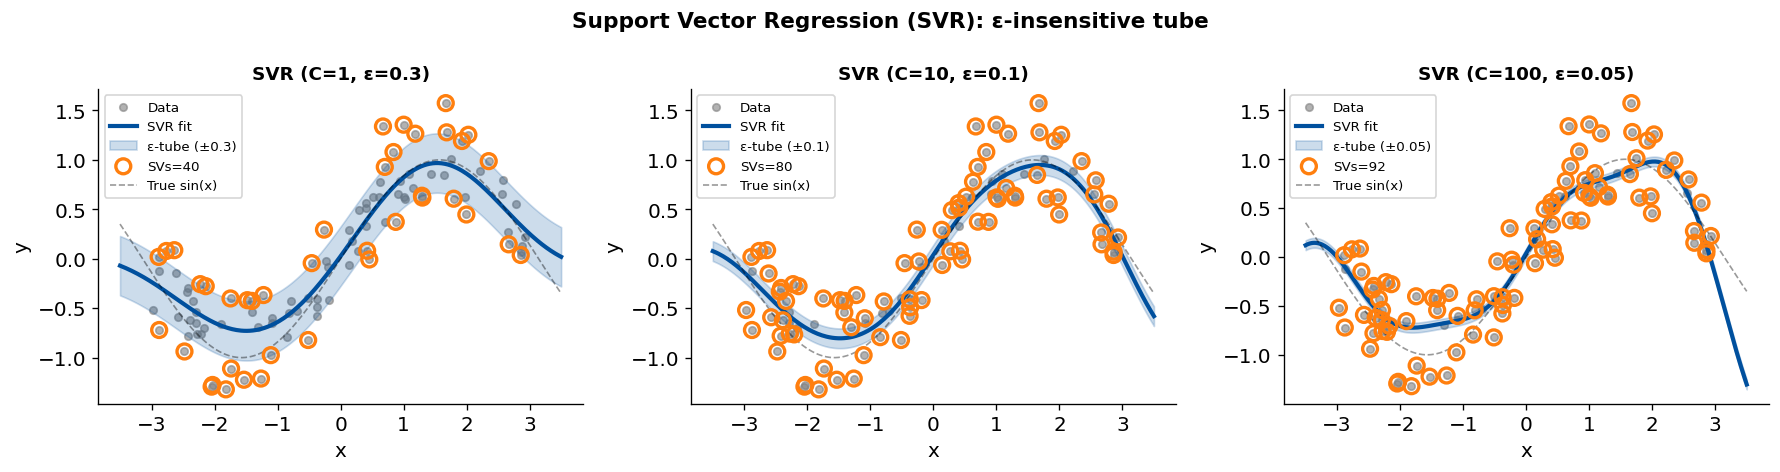

In [17]:
# ============================================================
# 10.1  Support Vector Regression (SVR) — brief demo
# ============================================================
from sklearn.svm import SVR

np.random.seed(0)
X_r = np.sort(np.random.uniform(-3, 3, 100))[:, np.newaxis]
y_r = np.sin(X_r[:,0]) + 0.3*np.random.randn(100)

x_test = np.linspace(-3.5, 3.5, 300)[:, np.newaxis]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
svr_configs = [
    ('rbf', {'C': 1,   'epsilon': 0.3}, 'SVR (C=1, ε=0.3)'),
    ('rbf', {'C': 10,  'epsilon': 0.1}, 'SVR (C=10, ε=0.1)'),
    ('rbf', {'C': 100, 'epsilon': 0.05},'SVR (C=100, ε=0.05)'),
]

for ax, (kern, kw, title) in zip(axes, svr_configs):
    svr = SVR(kernel=kern, **kw).fit(X_r, y_r)
    y_pred_r = svr.predict(x_test)

    ax.scatter(X_r, y_r, s=20, color='grey', alpha=0.6, label='Data')
    ax.plot(x_test, y_pred_r, color=BRAND_BLUE, lw=2.5, label='SVR fit')
    ax.fill_between(x_test[:,0],
                    y_pred_r - kw['epsilon'], y_pred_r + kw['epsilon'],
                    alpha=0.2, color=BRAND_BLUE, label=f'ε-tube (±{kw["epsilon"]})')
    ax.scatter(X_r[svr.support_], y_r[svr.support_],
               s=80, facecolors='none', edgecolors=ACCENT_ORANGE, lw=2,
               zorder=5, label=f'SVs={len(svr.support_)}')
    ax.plot(x_test, np.sin(x_test), 'k--', alpha=0.4, lw=1, label='True sin(x)')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8)

fig.suptitle('Support Vector Regression (SVR): ε-insensitive tube',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_svr.png', bbox_inches='tight')
plt.show()

---
## Summary Cheat Sheet

```
SVM QUICK REFERENCE
═══════════════════════════════════════════════════════════════
HARD MARGIN          min  ½‖w‖²
                     s.t. yᵢ(wᵀxᵢ+b) ≥ 1  ∀i

SOFT MARGIN          min  ½‖w‖² + C∑ξᵢ
                     s.t. yᵢ(wᵀxᵢ+b) ≥ 1-ξᵢ,  ξᵢ ≥ 0

DUAL                 max  ∑αᵢ - ½∑αᵢαⱼyᵢyⱼ(xᵢ·xⱼ)
                     s.t. 0 ≤ αᵢ ≤ C,  ∑αᵢyᵢ = 0

KERNEL TRICK         Replace xᵢ·xⱼ  →  K(xᵢ,xⱼ)

DECISION             f(x) = sign(∑_{SV} αᵢyᵢK(xᵢ,x) + b)

KERNELS              Linear:  xᵀz
                     Poly:    (xᵀz + c)^d
                     RBF:     exp(-γ‖x-z‖²)

PARAMETERS           C    ↑  → narrow margin, less tolerance
                     γ    ↑  → narrow kernel, more complex boundary

PRACTICAL TIPS       ✓ Always StandardScale first!
                     ✓ Use Pipeline(scaler, SVC)
                     ✓ Tune (C,γ) with GridSearchCV + CV
                     ✓ OvO for multi-class (sklearn default)
═══════════════════════════════════════════════════════════════
```